# GÓC NHÌN 3: PROMOTION EFFECTIVENESS
**Subsidizing Existing Customers at Negative Unit Economics**

> Story: Promo đang subsidize existing customers bằng negative unit economics,
> không tạo incremental demand.
>
> 3 trụ chứng cứ:
> - **(A)** Margin gap: promo −14.4% vs non-promo +19.97% → 34.4pp gap
> - **(B)** Daily correlation: r = −0.212, off-peak r = −0.135 → promo không bảo vệ volume
> - **(C)** Customer mix: 95.8% promo net sales từ existing customers

---

In [8]:
# ══════════════════════════════════════════════════════════════
# CELL 0 — Setup + Load + Fact Table
# ══════════════════════════════════════════════════════════════

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

# ── Locate repo root ──────────────────────────────────────────
ROOT = Path.cwd()
while ROOT.name != "VinDatathon_the-4-Outliers" and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if ROOT.name != "VinDatathon_the-4-Outliers":
    raise RuntimeError("Cannot locate repo root. "
                       "Run notebook từ bên trong VinDatathon_the-4-Outliers/")
CLEAN = ROOT / "data" / "clean"
OUT   = ROOT / "outputs"
OUT.mkdir(exist_ok=True)

import sys; sys.path.insert(0, str(ROOT))
from theme import (
    apply_theme, style_ax, COLORS,
    annotate_bar, add_insight, make_legend,
    CLR_SPINE, CLR_LABEL, CLR_MUTED
)
apply_theme()

# ── Load data ─────────────────────────────────────────────────
order_items = pd.read_parquet(CLEAN / 'order_items.parquet')
orders      = pd.read_parquet(CLEAN / 'orders.parquet')
products    = pd.read_parquet(CLEAN / 'products.parquet')
sales       = pd.read_parquet(CLEAN / 'sales.parquet')
payments    = pd.read_parquet(CLEAN / 'payments.parquet')
promotions  = pd.read_parquet(CLEAN / 'promotions.parquet')
web_traffic = pd.read_parquet(CLEAN / 'web_traffic.parquet')

print(f'order_items: {order_items.shape}')
print(f'orders:      {orders.shape}')
print(f'products:    {products.shape}')
print(f'sales:       {sales.shape}')
print(f'payments:    {payments.shape}')
print(f'promotions:  {promotions.shape}')
print(f'web_traffic: {web_traffic.shape}')

# ── Build fact table oi ───────────────────────────────────────
oi = order_items.merge(
    orders[['order_id', 'order_date', 'order_status', 'customer_id']], on='order_id')
oi = oi.merge(
    products[['product_id', 'cogs', 'segment', 'category']], on='product_id', how='left')

oi['discount_amount'] = oi['discount_amount'].fillna(0)
oi['line_revenue']    = oi['quantity'] * oi['unit_price']
oi['net_line']        = oi['line_revenue'] - oi['discount_amount']
oi['cogs_line']       = oi['quantity'] * oi['cogs']
oi['is_fulfilled']    = ~oi['order_status'].isin(['cancelled', 'created'])
oi['has_promo']       = (
    (oi['discount_amount'] > 0)
    | oi['promo_id'].fillna('No_Promo').ne('No_Promo')
    | oi['promo_id_2'].notna()
)
oi['date'] = pd.to_datetime(oi['order_date']).dt.normalize()

f = oi[oi['is_fulfilled']].copy()

print(f'\nFact table oi: {oi.shape}')
print(f'Fulfilled f:   {f.shape}')
print(f'has_promo rate (fulfilled): {f["has_promo"].mean()*100:.1f}%')

Vivid Slate theme applied.
order_items: (714669, 7)
orders:      (646945, 8)
products:    (2412, 8)
sales:       (3833, 3)
payments:    (646945, 4)
promotions:  (50, 10)
web_traffic: (3652, 7)

Fact table oi: (714669, 19)
Fulfilled f:   (641002, 19)
has_promo rate (fulfilled): 38.6%


In [9]:
# ══════════════════════════════════════════════════════════════
# CELL 1 — Reconciliation Assert
# ══════════════════════════════════════════════════════════════

tol = 1_000  # 1K VND tolerance

assert abs(oi['line_revenue'].sum() - sales['Revenue'].sum()) < tol, \
    f"Gross mismatch: {oi['line_revenue'].sum():,.0f} vs {sales['Revenue'].sum():,.0f}"

assert abs(oi['net_line'].sum() - payments['payment_value'].sum()) < tol, \
    f"Net mismatch: {oi['net_line'].sum():,.0f} vs {payments['payment_value'].sum():,.0f}"

assert abs(oi['cogs_line'].sum() - sales['COGS'].sum()) < tol, \
    f"COGS mismatch: {oi['cogs_line'].sum():,.0f} vs {sales['COGS'].sum():,.0f}"

print("\u2713 Reconciliation passed")
print(f"  Gross booked:  {oi['line_revenue'].sum()/1e9:.3f}B VND")
print(f"  Net paid:      {oi['net_line'].sum()/1e9:.3f}B VND")
print(f"  Discount burn: {(oi['line_revenue'].sum()-oi['net_line'].sum())/1e6:.1f}M VND")
print(f"  COGS total:    {oi['cogs_line'].sum()/1e9:.3f}B VND")

✓ Reconciliation passed
  Gross booked:  16.430B VND
  Net paid:      15.681B VND
  Discount burn: 749.6M VND
  COGS total:    14.163B VND


In [10]:
# ══════════════════════════════════════════════════════════════
# CELL 2 — KPI Contract Table
# ══════════════════════════════════════════════════════════════

def net_margin(d):
    return (d['net_line'].sum() - d['cogs_line'].sum()) / d['net_line'].sum() * 100

overall_margin = net_margin(f)
promo_margin   = net_margin(f[f['has_promo']])
nopromo_margin = net_margin(f[~f['has_promo']])

kpi = pd.DataFrame({
    'Metric': [
        'Net fulfilled sales', 'Net fulfilled margin (overall)',
        'Promo net fulfilled sales', 'Promo discount burn (fulfilled)',
        'Promo net margin', 'Non-promo net margin', 'Margin gap',
    ],
    'Value': [
        f"{f['net_line'].sum()/1e9:.2f}B VND",
        f"{overall_margin:.2f}%",
        f"{f[f['has_promo']]['net_line'].sum()/1e9:.2f}B VND",
        f"{f[f['has_promo']]['discount_amount'].sum()/1e6:.1f}M VND",
        f"{promo_margin:.2f}%",
        f"{nopromo_margin:.2f}%",
        f"{nopromo_margin - promo_margin:.2f}pp",
    ],
})
display(kpi)

print(f'\nExpected reference: ~14.05B / 9.69% / 4.20B / 671.9M / -14.44% / +19.97% / 34.41pp')
print('(Computed from data — minor differences are acceptable)')

,Metric,Value
0,Net fulfilled sales,14.05B VND
1,Net fulfilled margin (overall),9.69%
2,Promo net fulfilled sales,4.20B VND
3,Promo discount burn (fulfilled),671.9M VND
4,Promo net margin,-14.44%
5,Non-promo net margin,19.97%
6,Margin gap,34.41pp



Expected reference: ~14.05B / 9.69% / 4.20B / 671.9M / -14.44% / +19.97% / 34.41pp
(Computed from data — minor differences are acceptable)


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 3 — COMPOSITE FIGURE (3 panels)
# ══════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(14, 9))
gs  = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.35)
fig.subplots_adjust(top=0.90, bottom=0.08, left=0.08, right=0.98)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, :])

# ─────────────────────────────────────────────────────────────
# PANEL A — Net Fulfilled Margin: Promo vs Non-Promo
# ─────────────────────────────────────────────────────────────
labels = ['Non-promo', 'Overall', 'Promo']
values = [nopromo_margin, overall_margin, promo_margin]
colors = [COLORS['emerald'], COLORS['blue'], COLORS['red']]

bars = ax_a.barh(labels, values, color=colors, height=0.5)

for bar, val in zip(bars, values):
    ax_a.text(val + (0.5 if val >= 0 else -0.5), bar.get_y() + bar.get_height()/2,
              f'{val:.1f}%', va='center',
              ha='left' if val >= 0 else 'right',
              fontsize=10, color=CLR_LABEL)

ax_a.axvline(0, color=CLR_SPINE, lw=1, ls='--')
ax_a.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f}%"))

add_insight(ax_a, x=promo_margin, y='Promo',
            text=f'\u2212{nopromo_margin - promo_margin:.1f}pp gap',
            color=COLORS['violet'])

style_ax(ax_a,
    title='Net Fulfilled Margin',
    subtitle='',
    xlabel='Net Margin (%)')

# ─────────────────────────────────────────────────────────────
# PANEL B — More Promo ≠ More Revenue
# ─────────────────────────────────────────────────────────────
daily = f.groupby('date').agg(
    net_rev       = ('net_line', 'sum'),
    unique_buyers = ('customer_id', 'nunique'),
).reset_index()

promo_daily = f.groupby('date')['has_promo'].mean().rename('promo_rate').reset_index()
daily = daily.merge(promo_daily, on='date', how='left')

r_all     = daily['promo_rate'].corr(daily['net_rev'])
offpeak   = daily[~daily['date'].dt.month.isin([4, 5, 6])]
r_offpeak = offpeak['promo_rate'].corr(offpeak['net_rev'])
r_buyers  = daily['promo_rate'].corr(daily['unique_buyers'])

ax_b.scatter(daily['promo_rate'], daily['net_rev']/1e6,
             color=COLORS['violet'], alpha=0.2, s=15)

m, b = np.polyfit(daily['promo_rate'].dropna(),
                  daily.loc[daily['promo_rate'].notna(), 'net_rev']/1e6, 1)
x_line = np.linspace(daily['promo_rate'].min(), daily['promo_rate'].max(), 100)
ax_b.plot(x_line, m * x_line + b, color=COLORS['red'], lw=2)

annotation_text = (
    f"r = {r_all:.3f}  (all days)\n"
    f"r = {r_offpeak:.3f}  (off-peak only)\n"
    f"r = {r_buyers:.3f}  (vs daily unique buyers)"
)
ax_b.text(0.97, 0.97, annotation_text,
          transform=ax_b.transAxes, fontsize=9,
          va='top', ha='right',
          bbox=dict(facecolor='white', edgecolor=COLORS['violet'],
                    alpha=0.88, boxstyle='round,pad=0.4'))

style_ax(ax_b,
    title='Daily Promo Rate vs Net Fulfilled Revenue',
    subtitle='',
    xlabel='Daily promo line rate', ylabel='Net fulfilled revenue (M VND)')

# ─────────────────────────────────────────────────────────────
# PANEL C — Recent 10 Campaigns: Customer Mix
# Note: top 10 sorted by start_date (consistent with business_eda.ipynb)
# ─────────────────────────────────────────────────────────────
first_order = (
    f.groupby('customer_id', as_index=False)['date']
     .min()
     .rename(columns={'date': 'first_order_date'})
)
f_cust = f.merge(first_order, on='customer_id', how='left')

top10 = promotions.sort_values('start_date', ascending=False).head(10)

results = []
for _, p in top10.iterrows():
    pid = p['promo_id']
    camp_items = f_cust[
        (f_cust['promo_id'].eq(pid) | f_cust['promo_id_2'].eq(pid))
        & f_cust['has_promo']
        & f_cust['date'].between(p['start_date'], p['end_date'])
    ].copy()

    if camp_items.empty:
        continue

    camp_items['is_new'] = camp_items['first_order_date'] >= p['start_date']
    net_new      = camp_items.loc[camp_items['is_new'],  'net_line'].sum()
    net_existing = camp_items.loc[~camp_items['is_new'], 'net_line'].sum()
    net_total    = net_new + net_existing

    results.append({
        'name':         p['promo_name'],
        'start':        p['start_date'],
        'net_new':      net_new,
        'net_existing': net_existing,
        'net_total':    net_total,
        'new_pct':      net_new      / net_total * 100 if net_total else 0,
        'existing_pct': net_existing / net_total * 100 if net_total else 0,
    })

mix_df = pd.DataFrame(results).sort_values('start')  # oldest bottom, newest top

# Weighted aggregate
agg_existing_pct = mix_df['net_existing'].sum() / mix_df['net_total'].sum() * 100

ax_c.barh(mix_df['name'], mix_df['existing_pct'],
          color=COLORS['red'], label='Existing customers', height=0.6)
ax_c.barh(mix_df['name'], mix_df['new_pct'],
          left=mix_df['existing_pct'],
          color=COLORS['emerald'], label='New customers', height=0.6)

ax_c.set_xlim(0, 100)
# Reserve a small header band inside Panel C so callouts never cover data bars.
ax_c.set_ylim(-0.7, len(mix_df) + 1.2)
ax_c.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f}%"))

ax_c.text(0.99, 0.965,
          f"{agg_existing_pct:.1f}% of promo net sales = existing customers",
          transform=ax_c.transAxes, fontsize=10, fontweight='bold',
          va='top', ha='right', color=COLORS['violet'],
          bbox=dict(facecolor='white', edgecolor=COLORS['violet'],
                    alpha=0.9, boxstyle='round,pad=0.35'))

ax_c.text(0.01, 0.965, 'Red = existing customers   Green = new customers',
          transform=ax_c.transAxes, fontsize=9.5, color=CLR_LABEL,
          va='top', ha='left',
          bbox=dict(facecolor='white', edgecolor=CLR_SPINE,
                    alpha=0.9, boxstyle='round,pad=0.35'))

style_ax(ax_c,
    title='Customer Mix \u2014 10 Most Recent Campaigns',
    subtitle='',
    xlabel='Share of promo net sales (%)')

plt.suptitle(
    'Promotion Effectiveness: Subsidizing Existing Customers at Negative Margin',
    fontsize=13, fontweight='bold', y=0.985, color=CLR_LABEL)

OUT.mkdir(exist_ok=True)
plt.savefig(OUT / 'fig_promotion_effectiveness.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 4 — Counter-Argument Defense
# ══════════════════════════════════════════════════════════════

daily_rev = f.groupby('date')['net_line'].sum().reset_index(name='net_rev')
daily_rev['month']   = daily_rev['date'].dt.month
daily_rev['is_peak'] = daily_rev['month'].isin([4, 5, 6])

wt = web_traffic.copy()
wt['date'] = pd.to_datetime(wt['date']).dt.normalize()
daily_rev = daily_rev.merge(wt[['date', 'sessions']], on='date', how='left')

promo_daily = f.groupby('date')['has_promo'].mean().rename('promo_rate').reset_index()
daily_rev = daily_rev.merge(promo_daily, on='date', how='left')

peak    = daily_rev[daily_rev['is_peak']]
offpeak = daily_rev[~daily_rev['is_peak']]

rev_ratio      = peak['net_rev'].mean()  / offpeak['net_rev'].mean()
sessions_ratio = peak['sessions'].mean() / offpeak['sessions'].mean()
promo_peak     = peak['promo_rate'].mean()
promo_offpeak  = offpeak['promo_rate'].mean()

summary = pd.DataFrame({
    'Period':             ['Peak (Apr\u2013Jun)', 'Off-peak (rest of year)'],
    'Rev/day ratio':      [f'{rev_ratio:.2f}\u00d7', '1.00\u00d7'],
    'Sessions/day ratio': [f'{sessions_ratio:.2f}\u00d7', '1.00\u00d7'],
    'Avg promo rate':     [f'{promo_peak:.1%}', f'{promo_offpeak:.1%}'],
})
display(summary)
print(f"\nConclusion: Peak revenue is {rev_ratio:.2f}\u00d7 higher at LOWER promo rate "
      f"({promo_peak:.1%} vs {promo_offpeak:.1%}).")
print("Peak demand is organic. Promotions are concentrated in low-demand months.")
print("\n[Basis] Net fulfilled daily revenue. K3 canonical ref (gross monthly, business_eda): 1.81\u00d7, 23.8% vs 43.4%.")

Campaigns: 50, Cannibalized (net uplift < 0): 42/50


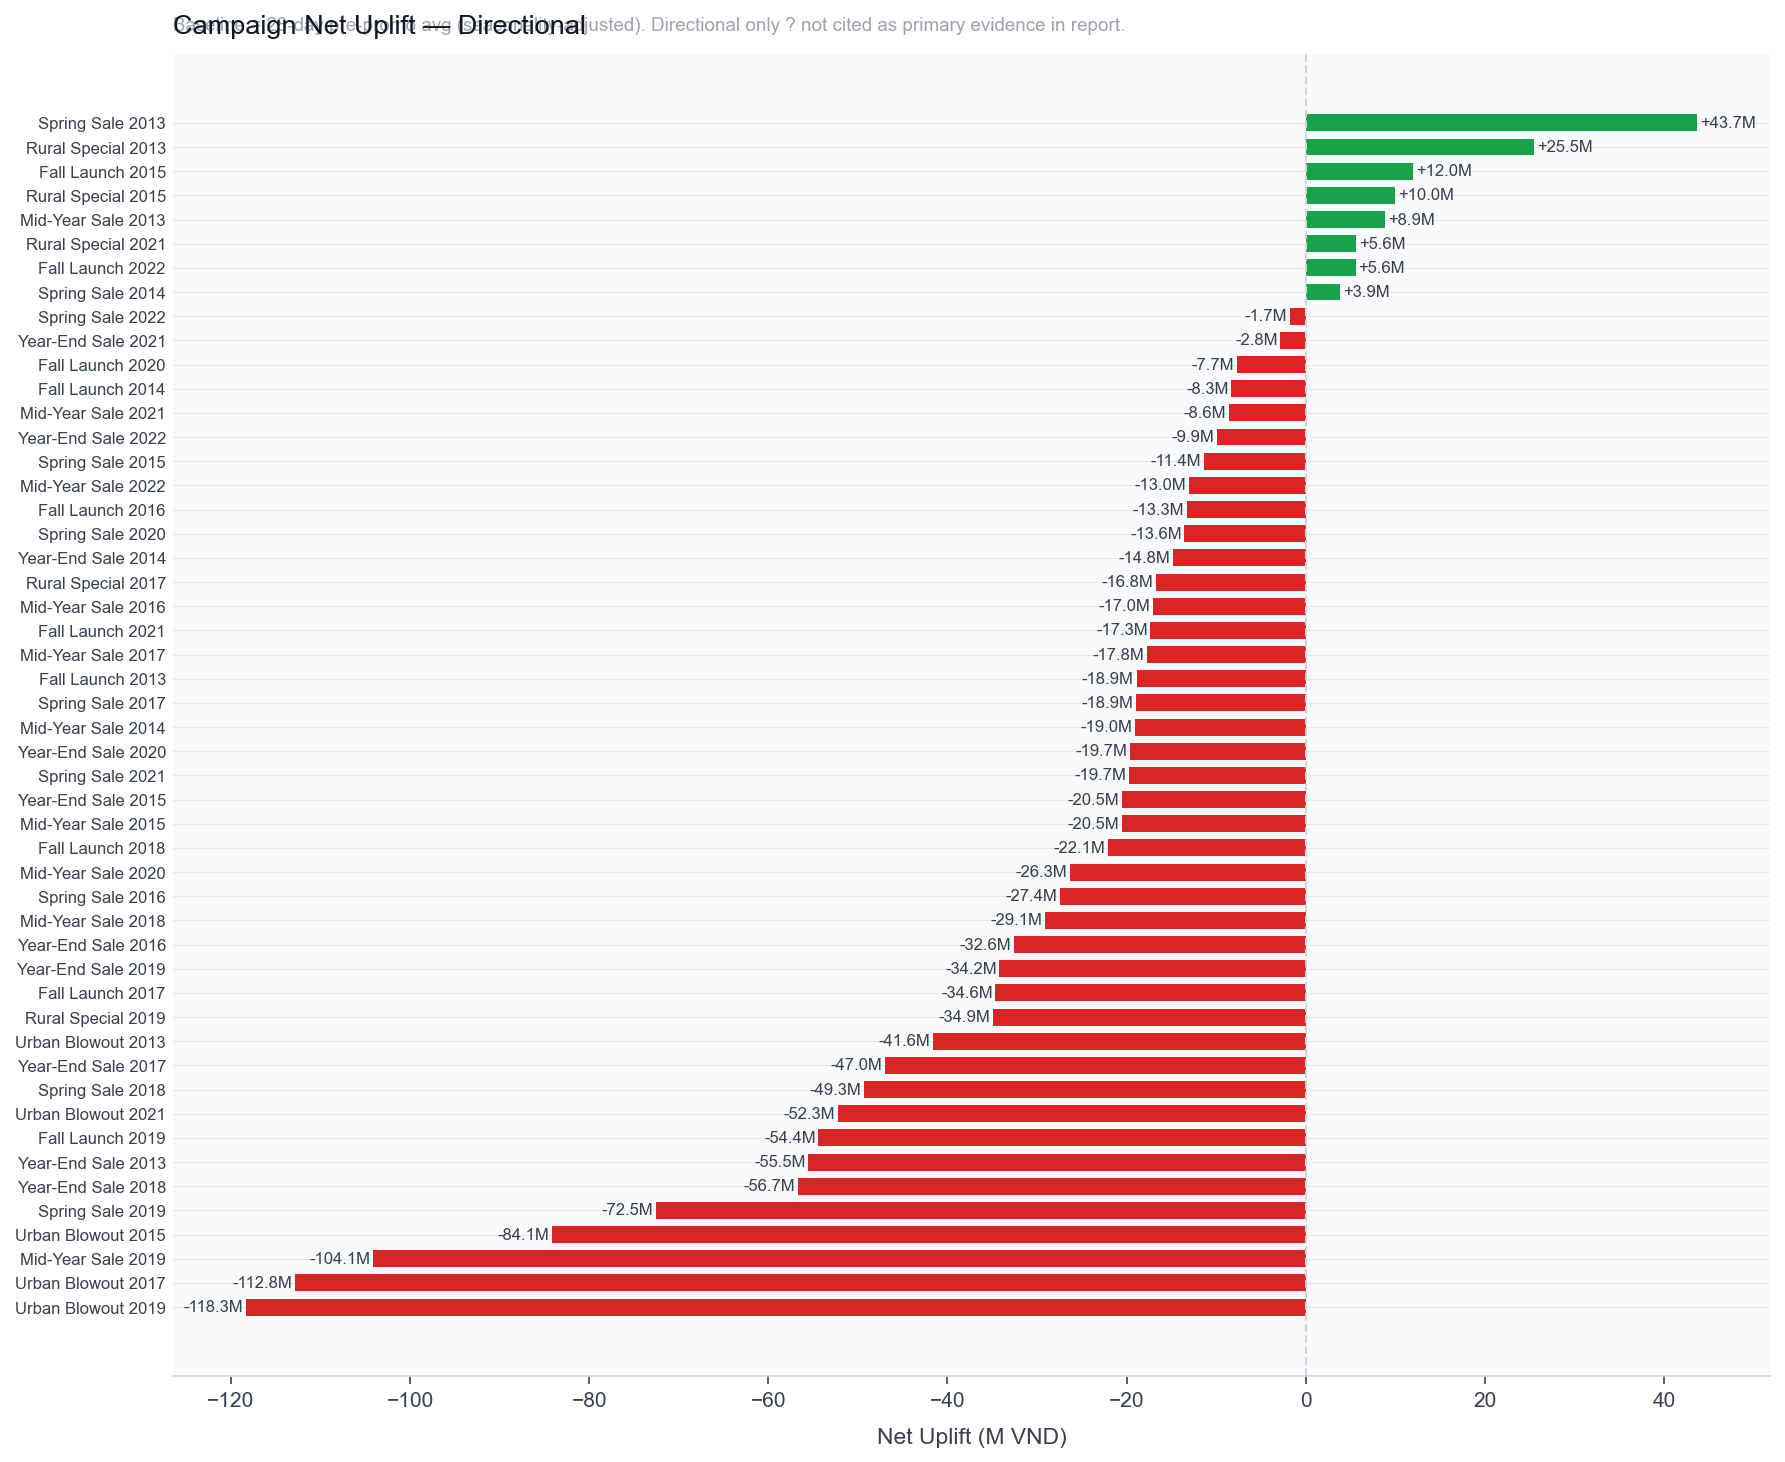

In [13]:
# ══════════════════════════════════════════════════════════════
# CELL 5 — APPENDIX: Campaign Waterfall (Directional)
# ══════════════════════════════════════════════════════════════

# Build baseline 28-day pre-promo with YoY seasonality adjustment
daily_sales = sales.copy()
daily_sales['date'] = pd.to_datetime(daily_sales['date']).dt.normalize()
daily_sales = daily_sales.set_index('date')['Revenue']

promo_metrics = []
for _, p in promotions.iterrows():
    pid   = p['promo_id']
    start = p['start_date']
    end   = p['end_date']
    dur   = (end - start).days + 1

    # Baseline: 28 days before start
    baseline_start = start - pd.Timedelta(days=28)
    baseline_end   = start - pd.Timedelta(days=1)
    baseline_rev = daily_sales.loc[baseline_start:baseline_end]
    baseline_daily_avg = baseline_rev.mean() if len(baseline_rev) > 0 else 0
    baseline_adjusted = baseline_daily_avg * dur

    # Seasonality: YoY ratio, clipped [0.5, 2.0]
    yoy_start = start - pd.DateOffset(years=1)
    yoy_end   = end - pd.DateOffset(years=1)
    yoy_rev   = daily_sales.loc[yoy_start:yoy_end]
    season_factor = 1.0
    if len(yoy_rev) > 0 and baseline_daily_avg > 0:
        yoy_daily_avg = yoy_rev.mean()
        season_factor = yoy_daily_avg / baseline_daily_avg
        season_factor = np.clip(season_factor, 0.5, 2.0)

    baseline_season_adj = baseline_adjusted * season_factor

    # Promo period revenue & discount
    promo_revenue  = daily_sales.loc[start:end].sum()
    promo_items = oi[
        (oi['promo_id'].eq(pid) | oi['promo_id_2'].eq(pid))
        & (oi['date'] >= start) & (oi['date'] <= end)
    ]
    total_discount = promo_items['discount_amount'].sum()

    uplift = promo_revenue - baseline_season_adj
    net_uplift = uplift - total_discount

    promo_metrics.append({
        'promo_id':    pid,
        'promo_name':  p['promo_name'],
        'start':       start,
        'net_uplift':  net_uplift,
    })

pm = pd.DataFrame(promo_metrics)
n_cannibal = (pm['net_uplift'] < 0).sum()
print(f'Campaigns: {len(pm)}, Cannibalized (net uplift < 0): {n_cannibal}/{len(pm)}')

# ── Waterfall chart ───────────────────────────────────────────
pm_sorted = pm.sort_values('net_uplift', ascending=True)
bar_colors = [COLORS['red'] if v < 0 else COLORS['emerald']
              for v in pm_sorted['net_uplift']]

fig_wf, ax_wf = plt.subplots(figsize=(12, 10))
ax_wf.barh(range(len(pm_sorted)), pm_sorted['net_uplift']/1e6,
           color=bar_colors, height=0.7)
ax_wf.axvline(0, color=CLR_SPINE, lw=1, ls='--')

for i, (v, name) in enumerate(zip(pm_sorted['net_uplift'], pm_sorted['promo_name'])):
    ax_wf.text(v/1e6 + (0.3 if v >= 0 else -0.3), i,
              f'{v/1e6:+.1f}M', va='center',
              ha='left' if v >= 0 else 'right',
              fontsize=8, color=CLR_LABEL)

ax_wf.set_yticks(range(len(pm_sorted)))
ax_wf.set_yticklabels(pm_sorted['promo_name'], fontsize=8)

style_ax(ax_wf,
    title='Campaign Net Uplift \u2014 Directional',
    subtitle='',
    xlabel='Net Uplift (M VND)')
ax_wf.text(
    0, 1.015,
    'Baseline = 28-day pre-promo avg (seasonality-adjusted). Directional only ? not cited as primary evidence in report.',
    transform=ax_wf.transAxes, fontsize=9, color=CLR_MUTED,
    va='bottom', ha='left'
)

plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.savefig(OUT / 'fig_waterfall_appendix.png', bbox_inches='tight', dpi=300)
plt.show()

In [14]:
# ══════════════════════════════════════════════════════════════
# CELL 6 — Prescriptive Scenario Table
# ══════════════════════════════════════════════════════════════

scenario = pd.DataFrame({
    'Lever': [
        'Cut 30% weak-promo exposure',
        'Upper-bound margin-gap recovery',
        'KPI target \u2014 margin',
        'KPI target \u2014 new-cust share',
    ],
    'Estimate': [
        '~202M VND discount avoided',
        '~433M VND',
        'Net fulfilled margin 9.7% \u2192 14\u201315%',
        'Promo new-cust share ~4% \u2192 >15%',
    ],
    'Condition / Note': [
        'Conservative \u2014 assumes volume loss < 5\u201310%',
        'Before volume-loss adjustment \u2014 upper bound',
        'Requires guardrail enforcement',
        'Guardrail: net margin \u2265 0%, regional holdout A/B',
    ],
})
display(scenario)

,Lever,Estimate,Condition / Note
0,Cut 30% weak-promo exposure,~202M VND discount avoided,Conservative — assumes volume loss < 5–10%
1,Upper-bound margin-gap recovery,~433M VND,Before volume-loss adjustment — upper bound
2,KPI target — margin,Net fulfilled margin 9.7% → 14–15%,Requires guardrail enforcement
3,KPI target — new-cust share,Promo new-cust share ~4% → >15%,"Guardrail: net margin ≥ 0%, regional holdout A/B"


---
## Report Snippet (copy to LaTeX)

> **I. Promotion Effectiveness: Subsidizing Existing Customers at Negative Net Margin**
>
> Promotions are not creating incremental growth; they are buying revenue from existing
> customers with negative unit economics. On a net fulfilled basis, promo-tagged fulfilled
> sales generated **4.20B VND** net sales while burning **671.9M VND** in discounts,
> driving promo net margin to **−14.4%** versus **+19.97%** for non-promo lines — a
> **34.4pp gap**. Daily promo intensity correlates negatively with net fulfilled revenue
> (**r = −0.212** overall, **r = −0.135** off-peak only), which does not support the
> hypothesis that promotions protect volume during slow periods. Correlation with daily
> unique buyers is near-zero (**r = +0.048**); in the 10 most recent campaigns, **95.8%**
> of promo net sales came from existing customers. Peak season (Apr–Jun) delivers **1.81×**
> daily revenue at lower promo rates (≈24% vs ≈43% off-peak), confirming peak demand is
> organic and does not require discount stimulation. **Recommendation:** cut the weakest
> 30% of broad-discount exposure; preserve first-purchase-only vouchers; require campaign
> guardrails — non-negative net margin, new-customer net share >15%, regional holdout A/B
> validation. Conservative discount exposure avoided: **~202M VND**; upper-bound
> margin-gap recovery: **~433M VND** before volume-loss adjustment.